In [ ]:
import torch
import numpy as np

from pathlib import Path
from PIL import Image
from torchvision import transforms


# -----------------------------
# User settings
# -----------------------------
REPO_DIR = Path(r"C:\Users\Wang2_h\dinov2")  # current folder should be the cloned dinov2 repo

WEIGHTS_NAME = "cell_dino_vits8_pretrain_cp-37d20e9c.pth"
IMAGE_NAME = "CC7_20x_1_C2_red.png"

WEIGHTS = REPO_DIR / "checkpoints" / WEIGHTS_NAME
IMAGE_PATH = REPO_DIR / "test_images" / IMAGE_NAME

MODEL_NAME = "cell_dino_cp_vits8"  # good first choice for HPA-like fluorescence
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

stem = Path(IMAGE_NAME).stem

out_dir = Path("test_results")
out_dir.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Load 8-bit single-channel fluorescence image
# -----------------------------
img = Image.open(IMAGE_PATH).convert("L")  # "L" = 8-bit grayscale

# H x W, values 0–255
arr = np.asarray(img).astype(np.float32)

# Convert 0–255 to 0–1
arr = arr / 255.0

# H x W x 1
single = arr[:, :, None]

# Duplicate single channel to 5 channels for Cell-DINO CP model
# H x W x 5
arr5 = np.concatenate([single, single, single, single, single], axis=2)

# 4 x H x W
x = torch.from_numpy(arr5).permute(2, 0, 1)

# Resize/crop to model input size.
# vitl16 uses img_size=224 in the hub definition.
preprocess = transforms.Compose([
    transforms.Resize((224, 224), antialias=True),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5, 0.5, 0.5],
    ),
])

x = preprocess(x).unsqueeze(0).to(DEVICE)


# -----------------------------
# Load Cell-DINO model
# -----------------------------
model = torch.hub.load(
    str(REPO_DIR),
    MODEL_NAME,
    source="local",
    pretrained_path=str(WEIGHTS),
)

model = model.to(DEVICE)
model.eval()


# -----------------------------
# Forward pass
# -----------------------------
with torch.no_grad():
    out = model.forward_features(x)

# DINO-style output usually contains:
# x_norm_clstoken: global image embedding
# x_norm_patchtokens: patch-level embeddings
global_embedding = out["x_norm_clstoken"]
patch_embeddings = out["x_norm_patchtokens"]

print("Global embedding shape:", global_embedding.shape)
print("Patch embedding shape:", patch_embeddings.shape)


np.save(
    out_dir / f"{stem}_global_embedding.npy",
    global_embedding.detach().cpu().numpy()
)

np.save(
    out_dir / f"{stem}_patch_embedding.npy",
    patch_embeddings.detach().cpu().numpy()
)

print("Saved:")
print("  custom_image_global_embedding.npy")
print("  custom_image_patch_embedding.npy")

RuntimeError: The size of tensor a (5) must match the size of tensor b (4) at non-singleton dimension 0

Original patch embedding shape: (1, 196, 1024)
Patch embeddings after squeeze: (196, 1024)
Patch grid: 14 14


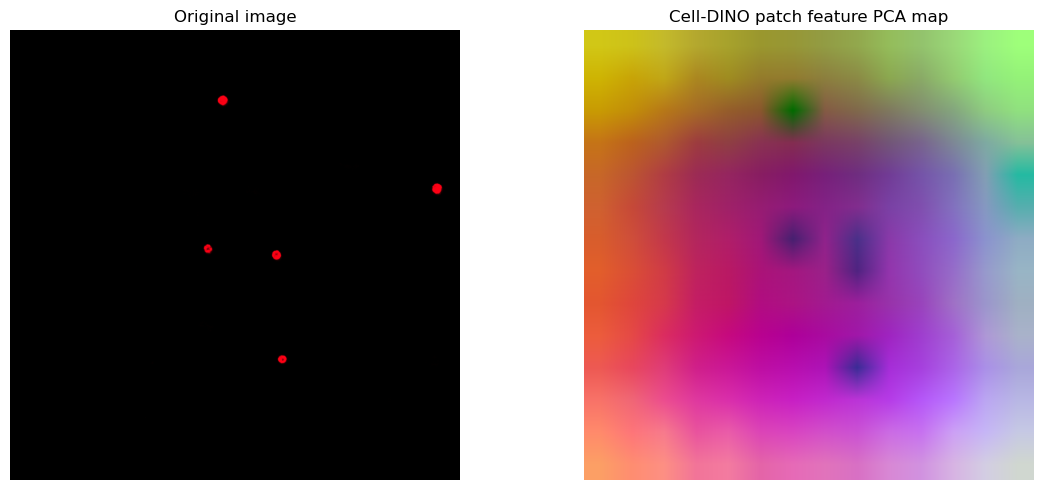

Saved: test_results\CC7_20x_1_C2_red_patch_pca_visualization.png


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from pathlib import Path
from PIL import Image

REPO_DIR = Path(r"C:\Users\Wang2_h\dinov2")  # current folder should be the cloned dinov2 repo

IMAGE_NAME = "CC7_20x_1_C2_red.png"
stem = Path(IMAGE_NAME).stem

image_path = REPO_DIR / "test_images" / IMAGE_NAME
patch_path = Path("test_results") / f"{stem}_patch_embedding.npy"

# Load image and embeddings
img = Image.open(image_path).convert("RGB")
patch_embeddings = np.load(patch_path)

print("Original patch embedding shape:", patch_embeddings.shape)

# Remove batch dimension if present
if patch_embeddings.ndim == 3:
    patch_embeddings = patch_embeddings[0]

print("Patch embeddings after squeeze:", patch_embeddings.shape)

num_patches, feature_dim = patch_embeddings.shape

# Infer patch grid size
grid_h = int(np.sqrt(num_patches))
grid_w = num_patches // grid_h

if grid_h * grid_w != num_patches:
    raise ValueError(
        f"Cannot infer square patch grid from {num_patches} patches. "
        "You need to set grid_h and grid_w manually."
    )

print("Patch grid:", grid_h, grid_w)

# PCA: high-dimensional feature -> 3 channels
pca = PCA(n_components=3)
features_3d = pca.fit_transform(patch_embeddings)

# Normalize to 0-1 for visualization
features_3d = features_3d - features_3d.min(axis=0)
features_3d = features_3d / (features_3d.max(axis=0) + 1e-8)

# Reshape to patch grid
pca_map = features_3d.reshape(grid_h, grid_w, 3)

# Resize to original image size
pca_img = Image.fromarray((pca_map * 255).astype(np.uint8))
pca_img = pca_img.resize(img.size, resample=Image.Resampling.BILINEAR)

# Show original and feature map
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title("Original image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(pca_img)
plt.title("Cell-DINO patch feature PCA map")
plt.axis("off")

plt.tight_layout()
plt.show()

out_path = Path("test_results") / f"{stem}_patch_pca_visualization.png"
pca_img.save(out_path)
print("Saved:", out_path)

Image path: C:\Users\Wang2_h\dinov2\test_images\CC7_20x_1_C2_red.png
PIL image mode: P
PIL image size: (3435, 3435)
NumPy array shape: (3435, 3435)
Data type: uint8
Minimum pixel value: 0
Maximum pixel value: 255
Top-left pixel value: 0


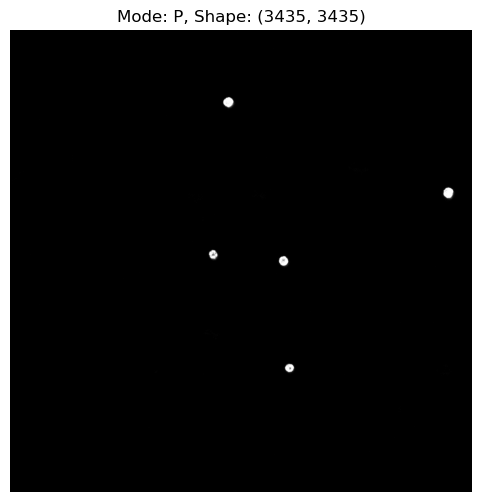

In [ ]:
from pathlib import Path
from PIL import Image

REPO_DIR = Path(r"C:\Users\Wang2_h\dinov2")  # current folder should be the cloned dinov2 repo

WEIGHTS_NAME = "cell_dino_vitl16_pretrain_hpa_fov-3505c6c0.pth"
IMAGE_NAME = "CC7_20x_1_C2_red.png"

WEIGHTS = REPO_DIR / "checkpoints" / WEIGHTS_NAME
IMAGE_PATH = REPO_DIR / "test_images" / IMAGE_NAME
img = Image.open(IMAGE_PATH)

# Basic PIL information

print("Image path:", IMAGE_PATH)

print("PIL image mode:", img.mode)

print("PIL image size:", img.size)  # (width, height)

# Convert to NumPy array

arr = np.asarray(img)

print("NumPy array shape:", arr.shape)

print("Data type:", arr.dtype)

print("Minimum pixel value:", arr.min())

print("Maximum pixel value:", arr.max())

# Display some pixel values

print("Top-left pixel value:", arr[0, 0])

# Display image

plt.figure(figsize=(6, 6))

if arr.ndim == 2:

    plt.imshow(arr, cmap="gray")

else:

    plt.imshow(arr)

plt.title(f"Mode: {img.mode}, Shape: {arr.shape}")

plt.axis("off")

plt.show()

In [5]:
import numpy as np
from PIL import Image
from pathlib import Path

REPO_DIR = Path(r"C:\Users\Wang2_h\dinov2")
IMAGE_NAME = "CC7_20x_1_C2_red.png"
IMAGE_PATH = REPO_DIR / "test_images" / IMAGE_NAME

img = Image.open(IMAGE_PATH)
arr = np.asarray(img)

OUT_PATH = REPO_DIR / "test_images" / "CC7_20x_1_C2_red_matrix_values.txt"

np.savetxt(OUT_PATH, arr, fmt="%d")

print("Saved full matrix values to:")
print(OUT_PATH)

Saved full matrix values to:
C:\Users\Wang2_h\dinov2\test_images\CC7_20x_1_C2_red_matrix_values.txt


In [2]:
import torch

from pathlib import Path

REPO_DIR = Path(r"C:\Users\Wang2_h\dinov2")

models = torch.hub.list(str(REPO_DIR), source="local")

for m in models:

    if "cell" in m.lower() or "dino" in m.lower():

        print(m)

TypeError: list() got an unexpected keyword argument 'source'